# 22. KAIST Perturbed Calibration Comparison

This notebook perturbs KAIST IMU and absolute LiDAR map-pose observations, then compares two modular `RollingGraph` runs: one with calibration variables fixed at their nominal values and one with calibration variables estimated per rolling window. LiDAR observations are absolute sensor poses `T_W_L` from notebook 21, not relative odometry factors.

## 1. Configuration

All editable experiment controls live here. The graph window follows notebook 19 exactly: `window_size = WINDOW_SIZE * 100` and `step_size = WINDOW_SIZE * 100 / 2`.

In [1]:
from pathlib import Path
import glob

# Dataset and output controls. Available choices on the KAIST disk are Urban08, Urban13, Urban14, and Urban16;
# numeric choices like 16 are also accepted.
KAIST_DATASETS_ROOT = Path('/mnt/d/Downloads/MobRobLab/KAISTDataset')
DATASET_CHOICE = 'Urban16'
OUTPUT_SUBDIR = 'notebook22_kaist_perturbed_calibration'
SAVE_FIGURES = True

# Load/run bounds. Keep this modest for interactive diagnosis; raise or set None for a longer run.
TARGET_IMU_FREQUENCY_HZ = 100.0
MAX_IMU_FILES = None
LIDAR_CSV_STRIDE = 1
MAX_LIDAR_POSES = None
REQUIRE_RIGHT_LIDAR = False
RUN_FIXED_GRAPH = True
RUN_FREE_GRAPH = True

# Rolling factor-graph controls, matching notebook 19 scaling.
WINDOW_SIZE = 5.0
IMU_SAMPLES_PER_FACTOR = None
LIDAR_SAMPLES_PER_FACTOR = None
LIDAR_MAP_POSE_FACTOR_STRIDE = 1
FACTOR_GRAPH_METHOD = 'LM'
ACC_MODE = 'simple'
IMU_TIME_OFFSET_MARGIN = 5.0
LIDAR_TIME_OFFSET_MARGIN = 5.0
SOLVER_SCHEDULER = [(1e-5, 100), (1e-5, 100), (1e-9, 100)]

# Measurement weights.
GYRO_INFORMATION = 1e6
ACCEL_INFORMATION = 1e0
LIDAR_MAP_POSE_INFORMATION_DIAG = [1e0, 1e0, 1e0, 1e2, 1e2, 1e2]

# Soft priors for the free-calibration graph. Fixed graph anchors variables instead of adding priors.
T_B_I_PRIOR_INFORMATION_DIAG = [1e1, 1e1, 1e1, 1e3, 1e3, 1e3]
T_B_L_PRIOR_INFORMATION_DIAG = [1e1, 1e1, 1e1, 1e3, 1e3, 1e3]
TAU_I_PRIOR_INFORMATION = 1e2
TAU_L_PRIOR_INFORMATION = 1e2
BIAS_PRIOR_INFORMATION = 1e5

# Nominal/reference calibration values used before perturbation.
TAU_I_REFERENCE = 0.0
TAU_LL_REFERENCE = 0.0
TAU_RL_REFERENCE = 0.0
BIAS_REFERENCE_LIST = [0.0, 0.0, 0.0]
GRAVITY_WORLD_LIST = [0.0, 0.0, 9.81]

# Artificial calibration perturbation laws.
T_B_I_LAW_MODE = 'constant'           # constant, linear, sinusoidal, piecewise
TAU_I_LAW_MODE = 'constant'
T_B_L_LAW_MODE = 'constant'
TAU_L_LAW_MODE = 'constant'
T_B_I_END_DELTA = [0.06, -0.04, 0.09, 0.05, -0.02, 0.03]
T_B_LL_END_DELTA = [0.04, -0.02, 0.03, 0.10, 0.00, 0.03]
T_B_RL_END_DELTA = [-0.04, 0.02, -0.03, -0.10, 0.00, 0.03]
TAU_I_END = 0.05
TAU_LL_END = 0.02
TAU_RL_END = -0.02
INCLUDE_LEVER_ARM_CORRECTION = False
ANGULAR_ACCELERATION_SMOOTHING_WINDOW = None

## 2. Imports And Paths

In [2]:
import sys

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / 'src' / 'multi_sensor_pipeline').exists():
        ROOT = candidate
        break
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

OUT = ROOT / 'outputs' / OUTPUT_SUBDIR
OUT.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import mrob
import numpy as np
import pandas as pd
from IPython.display import display

from kaist_dataset import load_imus
from kaist_dataset.data import import_true_trajectory
import multi_sensor_pipeline
from multi_sensor_pipeline import SolverConfig, TrajectoryConfig, VariableKey, VariableType, print_rolling_result_summary
from multi_sensor_pipeline.kaist_perturbation import (
    build_kaist_perturbation_laws,
    build_kaist_variable_configs,
    build_perturbed_kaist_streams,
    load_kaist_lidar_map_pose_observations,
    plot_calibration_truth_tracking,
    plot_fixed_free_chi2,
    plot_fixed_free_trajectories,
    run_kaist_perturbed_calibration_graph,
    summarize_perturbed_calibration_results,
)

available_dataset_paths = sorted(Path(path) for path in glob.glob(str(KAIST_DATASETS_ROOT / 'Urban*')) if Path(path).is_dir())
AVAILABLE_DATASETS = {path.name: path for path in available_dataset_paths if path.name in {'Urban08', 'Urban13', 'Urban14', 'Urban16'}}
DATASET_NAME = DATASET_CHOICE if str(DATASET_CHOICE).startswith('Urban') else f"Urban{int(DATASET_CHOICE):02d}"
if DATASET_NAME not in AVAILABLE_DATASETS:
    raise FileNotFoundError(f"Dataset {DATASET_NAME!r} was not found under {KAIST_DATASETS_ROOT}. Available: {sorted(AVAILABLE_DATASETS)}")

DATASET_ROOT = AVAILABLE_DATASETS[DATASET_NAME]
DATASET_SLUG = DATASET_NAME.lower()
SENSOR_DATA_ROOT = DATASET_ROOT / f'{DATASET_SLUG}_data' / DATASET_SLUG / 'sensor_data'
REFERENCE_POSE_PATH = DATASET_ROOT / f'{DATASET_SLUG}_pose' / DATASET_SLUG / 'global_pose.csv'
OUTPUT_DATA_ROOT = ROOT / 'data' / 'KAISTDataset' / DATASET_NAME
OUTPUT_DATA_ROOT.mkdir(parents=True, exist_ok=True)


def _single_glob(patterns, label):
    matches = []
    for pattern in patterns:
        matches.extend(Path(path) for path in glob.glob(str(pattern)))
    matches = sorted(set(path for path in matches if path.is_dir()))
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected exactly one {label} folder from patterns {patterns}, found {len(matches)}: {matches}")
    return matches[0]


LIDAR_VLP_LEFT_ROOT = _single_glob([SENSOR_DATA_ROOT / '*VLP*left*', SENSOR_DATA_ROOT / '*vlp*left*', SENSOR_DATA_ROOT / '*VLP*Left*'], 'left VLP')
LIDAR_VLP_RIGHT_ROOT = _single_glob([SENSOR_DATA_ROOT / '*VLP*right*', SENSOR_DATA_ROOT / '*vlp*right*', SENSOR_DATA_ROOT / '*VLP*Right*'], 'right VLP')
LIDAR_VLP_ROOTS = {
    'left': LIDAR_VLP_LEFT_ROOT,
    'right': LIDAR_VLP_RIGHT_ROOT,
}
IMU_ROOT = SENSOR_DATA_ROOT
LIDAR_MAP_POSE_CSV_LEFT = OUTPUT_DATA_ROOT / 'lidar_map_poses_vlp_left.csv'
LIDAR_MAP_POSE_CSV_RIGHT = OUTPUT_DATA_ROOT / 'lidar_map_poses_vlp_right.csv'

BIAS_REFERENCE = np.asarray(BIAS_REFERENCE_LIST, dtype=float)
GRAVITY_WORLD = np.asarray(GRAVITY_WORLD_LIST, dtype=float)
LIDAR_MAP_POSE_INFORMATION = np.diag(LIDAR_MAP_POSE_INFORMATION_DIAG)
T_B_I_PRIOR_INFORMATION = np.diag(T_B_I_PRIOR_INFORMATION_DIAG)
T_B_L_PRIOR_INFORMATION = np.diag(T_B_L_PRIOR_INFORMATION_DIAG)

print(f'Dataset: {DATASET_NAME} -> {DATASET_ROOT}')
print(f'Sensor data root: {SENSOR_DATA_ROOT}')
print(f'Left VLP root: {LIDAR_VLP_LEFT_ROOT}')
print(f'Right VLP root: {LIDAR_VLP_RIGHT_ROOT}')
print(f'Left LiDAR map pose CSV: {LIDAR_MAP_POSE_CSV_LEFT}')
print(f'Right LiDAR map pose CSV: {LIDAR_MAP_POSE_CSV_RIGHT}')

Dataset: Urban16 -> /mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16
Sensor data root: /mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16/urban16_data/urban16/sensor_data
Left VLP root: /mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16/urban16_data/urban16/sensor_data/VLP_left
Right VLP root: /mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16/urban16_data/urban16/sensor_data/VLP_right
Left LiDAR map pose CSV: /home/camel/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_map_poses_vlp_left.csv
Right LiDAR map pose CSV: /home/camel/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_map_poses_vlp_right.csv


## 3. KAIST Nominal Extrinsics

In [3]:
# T_A_B maps coordinates from frame B to frame A.
# T_B_LL maps Left LiDAR coordinates into the KAIST body/vehicle frame.
T_B_LL_REFERENCE = np.array([
    [-0.514066, -0.702201, -0.492595, -0.440699],
    [ 0.486485, -0.711672,  0.506809,  0.397052],
    [-0.706447,  0.0208933,  0.707457,  1.90953],
    [ 0.0,       0.0,        0.0,       1.0],
], dtype=float)

# T_B_RL maps Right LiDAR coordinates into the KAIST body/vehicle frame.
T_B_RL_REFERENCE = np.array([
    [-0.512152,  0.699241, -0.498761, -0.449885],
    [-0.494811, -0.714859, -0.494104, -0.416713],
    [-0.702041, -0.0062642, 0.712109,  1.91294],
    [ 0.0,       0.0,       0.0,       1.0],
], dtype=float)

T_I_B_REFERENCE = np.array([
    [1.0, 0.0, 0.0, -0.07],
    [0.0, 1.0, 0.0,  0.00],
    [0.0, 0.0, 1.0,  1.70],
    [0.0, 0.0, 0.0,  1.00],
])
T_B_I_REFERENCE = np.linalg.inv(T_I_B_REFERENCE)

print('T_B_LL reference tangent:', mrob.SE3(T_B_LL_REFERENCE).Ln())
print('T_B_RL reference tangent:', mrob.SE3(T_B_RL_REFERENCE).Ln())
print('T_B_I reference tangent:', mrob.SE3(T_B_I_REFERENCE).Ln())

T_B_LL reference tangent: [-0.90803571  0.39962948  2.22131152 -0.54393308 -0.02053702  1.94245679]
T_B_RL reference tangent: [ 0.90791977  0.37832564 -2.22225243 -0.50817814  0.01112482  1.96196077]
T_B_I reference tangent: [-0.    0.   -0.    0.07  0.   -1.7 ]


## 4. Load KAIST Streams

In [4]:
imu_streams_raw = load_imus(IMU_ROOT, target_frequency_hz=TARGET_IMU_FREQUENCY_HZ, max_files=MAX_IMU_FILES)
primary_imu_name = list(imu_streams_raw.keys())[0]
primary_imu = imu_streams_raw[primary_imu_name]

true_timestamps, true_poses = import_true_trajectory(REFERENCE_POSE_PATH)

lidar_left, lidar_right = load_kaist_lidar_map_pose_observations(
    LIDAR_MAP_POSE_CSV_LEFT,
    LIDAR_MAP_POSE_CSV_RIGHT,
    stride=LIDAR_CSV_STRIDE,
    max_poses=MAX_LIDAR_POSES,
    require_left=True,
    require_right=REQUIRE_RIGHT_LIDAR,
)

print('Primary IMU:', primary_imu_name, primary_imu.timestamps_s.shape)
print('IMU time range:', primary_imu.timestamps_s[0], '...', primary_imu.timestamps_s[-1])
print('Reference trajectory:', true_poses.shape, true_timestamps[0], '...', true_timestamps[-1])
print('Left LiDAR map poses:', lidar_left.poses_T_W_L.shape, lidar_left.timestamps_s[0], '...', lidar_left.timestamps_s[-1])
print('Right LiDAR map poses:', None if lidar_right is None else lidar_right.poses_T_W_L.shape)
if lidar_right is None:
    print('Right LiDAR CSV is optional and was not used:', LIDAR_MAP_POSE_CSV_RIGHT)

Primary IMU: sensor_data_xsens_imu (449195,)
IMU time range: 1524205092.9013677 ... 1524209584.8413677
Reference trajectory: (308734, 4, 4) 1524205131.6004922 ... 1524209584.84052
Left LiDAR map poses: (37704, 4, 4) 1524205126.62 ... 1524209584.81
Right LiDAR map poses: (37705, 4, 4)


## 5. Build Perturbation Laws

In [5]:
law_t_start = max(primary_imu.timestamps_s[0] - TAU_I_REFERENCE, lidar_left.timestamps_s[0] - TAU_LL_REFERENCE)
law_t_end = min(primary_imu.timestamps_s[-1] - TAU_I_REFERENCE, lidar_left.timestamps_s[-1] - TAU_LL_REFERENCE)
if lidar_right is not None:
    law_t_start = max(law_t_start, lidar_right.timestamps_s[0] - TAU_RL_REFERENCE)
    law_t_end = min(law_t_end, lidar_right.timestamps_s[-1] - TAU_RL_REFERENCE)

laws = build_kaist_perturbation_laws(
    t_start_s=law_t_start,
    t_end_s=law_t_end,
    T_B_I_reference=T_B_I_REFERENCE,
    tau_I_reference=TAU_I_REFERENCE,
    T_B_LL_reference=T_B_LL_REFERENCE,
    tau_LL_reference=TAU_LL_REFERENCE,
    T_B_RL_reference=T_B_RL_REFERENCE if lidar_right is not None else None,
    tau_RL_reference=TAU_RL_REFERENCE,
    T_B_I_mode=T_B_I_LAW_MODE,
    T_B_I_end_delta=T_B_I_END_DELTA,
    tau_I_mode=TAU_I_LAW_MODE,
    tau_I_end=TAU_I_END,
    T_B_L_mode=T_B_L_LAW_MODE,
    T_B_LL_end_delta=T_B_LL_END_DELTA,
    T_B_RL_end_delta=T_B_RL_END_DELTA,
    tau_L_mode=TAU_L_LAW_MODE,
    tau_LL_end=TAU_LL_END,
    tau_RL_end=TAU_RL_END,
)

check_times = np.linspace(law_t_start, law_t_end, 5)
print('law time range:', law_t_start, '...', law_t_end)
print('T_B_I truth tangents:\n', np.vstack([mrob.SE3(T).Ln() for T in laws.T_B_I_law(check_times)]))
print('tau_I truth:', laws.tau_I_law(check_times))
print('T_B_LL truth tangents:\n', np.vstack([mrob.SE3(T).Ln() for T in laws.T_B_LL_law(check_times)]))
print('tau_LL truth:', laws.tau_LL_law(check_times))

law time range: 1524205126.7 ... 1524209584.79
T_B_I truth tangents:
 [[ 0.06       -0.04        0.09        0.08517823 -0.07365389 -1.67063166]
 [ 0.06       -0.04        0.09        0.08517823 -0.07365389 -1.67063166]
 [ 0.06       -0.04        0.09        0.08517823 -0.07365389 -1.67063166]
 [ 0.06       -0.04        0.09        0.08517823 -0.07365389 -1.67063166]
 [ 0.06       -0.04        0.09        0.08517823 -0.07365389 -1.67063166]]
tau_I truth: [0.05 0.05 0.05 0.05 0.05]
T_B_LL truth tangents:
 [[-0.86334459  0.44948349  2.23987896 -0.51504512  0.17173828  1.91626088]
 [-0.86334459  0.44948349  2.23987896 -0.51504512  0.17173828  1.91626088]
 [-0.86334459  0.44948349  2.23987896 -0.51504512  0.17173828  1.91626088]
 [-0.86334459  0.44948349  2.23987896 -0.51504512  0.17173828  1.91626088]
 [-0.86334459  0.44948349  2.23987896 -0.51504512  0.17173828  1.91626088]]
tau_LL truth: [0.02 0.02 0.02 0.02 0.02]


## 6. Create Perturbed Pipeline Streams

In [6]:
perturbed = build_perturbed_kaist_streams(
    imu_timestamps_s=primary_imu.timestamps_s,
    gyroscope_radps=primary_imu.gyro_radps,
    accelerometer_mps2=primary_imu.accel_mps2,
    lidar_left=lidar_left,
    lidar_right=lidar_right,
    laws=laws,
    T_B_I_reference=T_B_I_REFERENCE,
    tau_I_reference=TAU_I_REFERENCE,
    T_B_LL_reference=T_B_LL_REFERENCE,
    T_B_RL_reference=T_B_RL_REFERENCE if lidar_right is not None else None,
    tau_LL_reference=TAU_LL_REFERENCE,
    tau_RL_reference=TAU_RL_REFERENCE,
    accel_mode=ACC_MODE,
    imu_samples_per_factor=IMU_SAMPLES_PER_FACTOR,
    lidar_samples_per_factor=LIDAR_SAMPLES_PER_FACTOR,
    imu_time_offset_margin=IMU_TIME_OFFSET_MARGIN,
    lidar_time_offset_margin=LIDAR_TIME_OFFSET_MARGIN,
    gyro_information=GYRO_INFORMATION,
    accel_information=ACCEL_INFORMATION,
    lidar_pose_information=LIDAR_MAP_POSE_INFORMATION,
    lidar_factor_stride=LIDAR_MAP_POSE_FACTOR_STRIDE,
    gravity_world=GRAVITY_WORLD,
    bias_reference=BIAS_REFERENCE,
    include_lever_arm_correction=INCLUDE_LEVER_ARM_CORRECTION,
    angular_acceleration_smoothing_window=ANGULAR_ACCELERATION_SMOOTHING_WINDOW,
)

print('Streams:', [stream.stream_name for stream in perturbed.streams])
print('Sensors:', [sensor.sensor_id for sensor in perturbed.sensors])
print('Pose timestamps:', perturbed.pose_timestamps_s.shape, perturbed.pose_timestamps_s[0], '...', perturbed.pose_timestamps_s[-1])
print('Initial body poses:', perturbed.initial_body_poses_T_W_B.shape)
print('Perturbed IMU timestamp shift range [s]:', float(np.min(perturbed.emulated_imu.sensor_timestamps - primary_imu.timestamps_s)), float(np.max(perturbed.emulated_imu.sensor_timestamps - primary_imu.timestamps_s)))

Streams: ['imu_0.gyro', 'imu_0.accel', 'lidar_0.perturbed_map_pose', 'lidar_1.perturbed_map_pose']
Sensors: ['imu_0', 'lidar_0', 'lidar_1']
Pose timestamps: (37702,) 1524205126.74 ... 1524209584.73
Initial body poses: (37702, 4, 4)
Perturbed IMU timestamp shift range [s]: 0.04999995231628418 0.04999995231628418


## 7. Visual Sanity Check Of Perturbed Inputs

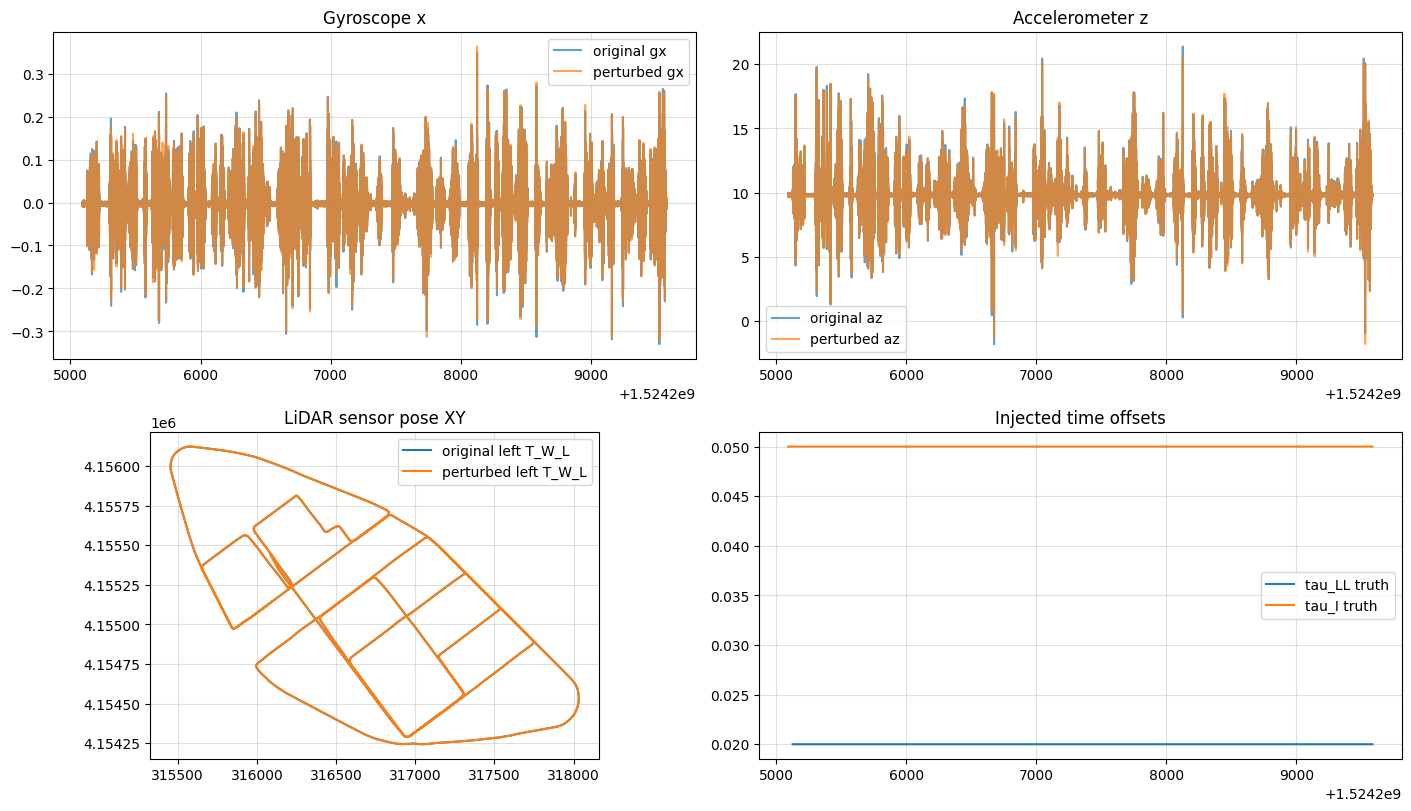

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
axes[0, 0].plot(primary_imu.timestamps_s, primary_imu.gyro_radps[:, 0], alpha=0.7, label='original gx')
axes[0, 0].plot(perturbed.emulated_imu.sensor_timestamps, perturbed.emulated_imu.gyroscope[:, 0], alpha=0.7, label='perturbed gx')
axes[0, 0].set_title('Gyroscope x')
axes[0, 0].legend()
axes[0, 1].plot(primary_imu.timestamps_s, primary_imu.accel_mps2[:, 2], alpha=0.7, label='original az')
axes[0, 1].plot(perturbed.emulated_imu.sensor_timestamps, perturbed.emulated_imu.accelerometer[:, 2], alpha=0.7, label='perturbed az')
axes[0, 1].set_title('Accelerometer z')
axes[0, 1].legend()
axes[1, 0].plot(lidar_left.poses_T_W_L[:, 0, 3], lidar_left.poses_T_W_L[:, 1, 3], label='original left T_W_L')
axes[1, 0].plot(perturbed.lidar_left.poses_T_W_L[:, 0, 3], perturbed.lidar_left.poses_T_W_L[:, 1, 3], label='perturbed left T_W_L')
axes[1, 0].set_aspect('equal', adjustable='box')
axes[1, 0].set_title('LiDAR sensor pose XY')
axes[1, 0].legend()
axes[1, 1].plot(perturbed.lidar_left.reference_timestamps_s, perturbed.lidar_left.tau_L_truth, label='tau_LL truth')
axes[1, 1].plot(perturbed.emulated_imu.reference_timestamps, perturbed.emulated_imu.tau_I_truth, label='tau_I truth')
axes[1, 1].set_title('Injected time offsets')
axes[1, 1].legend()
for axis in axes.ravel():
    axis.grid(True, alpha=0.25)
if SAVE_FIGURES:
    fig.savefig(OUT / 'perturbed_input_streams.png', dpi=160)
plt.show()
plt.close(fig)

## 8. Run Fixed And Free Calibration Graphs

In [8]:
right_sensor_id = None if perturbed.lidar_right is None else perturbed.lidar_right.sensor_id
solver_config = SolverConfig(method=FACTOR_GRAPH_METHOD, scheduler=SOLVER_SCHEDULER, solver_verbose=False)
trajectory_config = TrajectoryConfig(anchor_first_pose=True, anchor_first_pose_each_window=False, anchor_last_pose=False, anchor_all_poses=False, use_imu_gyr=False)

fixed_variable_configs = build_kaist_variable_configs(
    True,
    T_B_I_initial=T_B_I_REFERENCE,
    tau_I_initial=TAU_I_REFERENCE,
    gyro_bias_initial=BIAS_REFERENCE,
    T_B_LL_initial=T_B_LL_REFERENCE,
    tau_LL_initial=TAU_LL_REFERENCE,
    right_lidar_sensor_id=right_sensor_id,
    T_B_RL_initial=T_B_RL_REFERENCE,
    tau_RL_initial=TAU_RL_REFERENCE,
)

free_variable_configs = build_kaist_variable_configs(
    False,
    T_B_I_initial=T_B_I_REFERENCE,
    tau_I_initial=TAU_I_REFERENCE,
    gyro_bias_initial=BIAS_REFERENCE,
    T_B_LL_initial=T_B_LL_REFERENCE,
    tau_LL_initial=TAU_LL_REFERENCE,
    right_lidar_sensor_id=right_sensor_id,
    T_B_RL_initial=T_B_RL_REFERENCE,
    tau_RL_initial=TAU_RL_REFERENCE,
    T_B_I_prior_information=T_B_I_PRIOR_INFORMATION,
    tau_I_prior_information=TAU_I_PRIOR_INFORMATION,
    gyro_bias_prior_information=BIAS_PRIOR_INFORMATION,
    T_B_L_prior_information=T_B_L_PRIOR_INFORMATION,
    tau_L_prior_information=TAU_L_PRIOR_INFORMATION,
    initial_source="numerical",
)

runs = []
if RUN_FIXED_GRAPH:
    fixed_run = run_kaist_perturbed_calibration_graph(
        label='fixed calibration',
        fixed_calibration=True,
        perturbed_streams=perturbed,
        variable_configs=fixed_variable_configs,
        window_size=WINDOW_SIZE,
        solver_config=solver_config,
        trajectory_config=trajectory_config,
        verbose=0,
    )
    runs.append(fixed_run)
    print('Fixed graph solved windows:', len(fixed_run.results))
    if fixed_run.results:
        print_rolling_result_summary(fixed_run.results[-1])

if RUN_FREE_GRAPH:
    free_run = run_kaist_perturbed_calibration_graph(
        label='free calibration',
        fixed_calibration=False,
        perturbed_streams=perturbed,
        variable_configs=free_variable_configs,
        window_size=WINDOW_SIZE,
        solver_config=solver_config,
        trajectory_config=trajectory_config,
        verbose=0,
    )
    runs.append(free_run)
    print('Free graph solved windows:', len(free_run.results))
    if free_run.results:
        print_rolling_result_summary(free_run.results[-1])

for run in runs:
    print(run.label, 'window_size_s=', run.window_size_s, 'step_size_s=', run.step_size_s, 'trajectory=', run.estimated_poses_T_W_B.shape)

 89%|████████▉ | 16/18 [08:25<01:03, 31.58s/it]


Fixed graph solved windows: 17
window 16: [1524209131.680, 1524209579.770]
poses: 3881
chi2: 6.442075e+04 -> 3.044436e+04
factor counts: {'gyro_calib_prop': 3880, 'accel_gravity_calib': 3881, 'lidar_calib_pose': 7762}
imu_0:extrinsic Ln: [-0.    0.   -0.    0.07  0.   -1.7 ]
imu_0:gyro_bias: [0. 0. 0.]
imu_0:time_offset: 0.0
lidar_0:extrinsic Ln: [-0.90803571  0.39962948  2.22131152 -0.54393308 -0.02053702  1.94245679]
lidar_0:time_offset: 0.0
lidar_1:extrinsic Ln: [ 0.90791977  0.37832564 -2.22225243 -0.50817814  0.01112482  1.96196077]
lidar_1:time_offset: 0.0


 89%|████████▉ | 16/18 [09:35<01:11, 35.98s/it]

Free graph solved windows: 17
window 16: [1524209131.680, 1524209579.770]
poses: 3881
chi2: 1.132185e+05 -> 6.559279e+03
factor counts: {'gyro_calib_prop': 3880, 'accel_gravity_calib': 3881, 'lidar_calib_pose': 7762, 'extrinsic_prior': 3, 'gyro_bias_prior': 1, 'time_offset_prior': 3}
imu_0:extrinsic Ln: [ 0.07211638 -0.06935268  0.23213202  0.12623292  0.07167746 -1.69605522]
imu_0:gyro_bias: [-0.00324485 -0.00156336 -0.00115475]
imu_0:time_offset: -0.0038076994598628157
lidar_0:extrinsic Ln: [-0.89717399  0.40988121  2.22616736 -0.61559213  0.06328064  1.8062151 ]
lidar_0:time_offset: 0.051994067434410984
lidar_1:extrinsic Ln: [ 0.96781293  0.44267754 -2.18999304 -0.56400082  0.07644845  2.03079264]
lidar_1:time_offset: 0.00611979725663396
fixed calibration window_size_s= 500.0 step_size_s= 250.0 trajectory= (37603, 4, 4)
free calibration window_size_s= 500.0 step_size_s= 250.0 trajectory= (37603, 4, 4)


## 9. Diagnostics Tables

In [9]:
summary = summarize_perturbed_calibration_results(runs, laws)
display(summary)

compact = summary[['run', 'window', 'start', 'end', 'chi2_before', 'chi2_after']].copy() if not summary.empty else summary
display(compact)

,run,fixed_calibration,window,start,end,midpoint,chi2_before,chi2_after,imu_0_extrinsic_ln,imu_0_gyro_bias,imu_0_time_offset,lidar_0_extrinsic_ln,lidar_0_time_offset,lidar_1_extrinsic_ln,lidar_1_time_offset
0,fixed calibration,True,0,1.524205e+09,1.524206e+09,1.524205e+09,101687.548692,31706.538741,"[-0.0, 0.0, -0.0, 0.07, 0.0, -1.7]","[0.0, 0.0, 0.0]",0.000000,"[-0.9080357110752991, 0.39962948188351266, 2.2...",0.000000,"[0.9079197719723768, 0.3783256374041921, -2.22...",0.000000
1,fixed calibration,True,1,1.524205e+09,1.524206e+09,1.524206e+09,81258.583365,39403.410613,"[-0.0, 0.0, -0.0, 0.07, 0.0, -1.7]","[0.0, 0.0, 0.0]",0.000000,"[-0.9080357110752991, 0.39962948188351266, 2.2...",0.000000,"[0.9079197719723768, 0.3783256374041921, -2.22...",0.000000
2,fixed calibration,True,2,1.524206e+09,1.524206e+09,1.524206e+09,61069.457561,39408.809537,"[-0.0, 0.0, -0.0, 0.07, 0.0, -1.7]","[0.0, 0.0, 0.0]",0.000000,"[-0.9080357110752991, 0.39962948188351266, 2.2...",0.000000,"[0.9079197719723768, 0.3783256374041921, -2.22...",0.000000
3,fixed calibration,True,3,1.524206e+09,1.524206e+09,1.524206e+09,45338.795326,26821.445557,"[-0.0, 0.0, -0.0, 0.07, 0.0, -1.7]","[0.0, 0.0, 0.0]",0.000000,"[-0.9080357110752991, 0.39962948188351266, 2.2...",0.000000,"[0.9079197719723768, 0.3783256374041921, -2.22...",0.000000
4,fixed calibration,True,4,1.524206e+09,1.524207e+09,1.524206e+09,59341.756897,28270.160165,"[-0.0, 0.0, -0.0, 0.07, 0.0, -1.7]","[0.0, 0.0, 0.0]",0.000000,"[-0.9080357110752991, 0.39962948188351266, 2.2...",0.000000,"[0.9079197719723768, 0.3783256374041921, -2.22...",0.000000
5,fixed calibration,True,5,1.524206e+09,1.524207e+09,1.524207e+09,71073.288262,38048.577613,"[-0.0, 0.0, -0.0, 0.07, 0.0, -1.7]","[0.0, 0.0, 0.0]",0.000000,"[-0.9080357110752991, 0.39962948188351266, 2.2...",0.000000,"[0.9079197719723768, 0.3783256374041921, -2.22...",0.000000
6,fixed calibration,True,6,1.524207e+09,1.524207e+09,1.524207e+09,73521.283381,33172.241495,"[-0.0, 0.0, -0.0, 0.07, 0.0, -1.7]","[0.0, 0.0, 0.0]",0.000000,"[-0.9080357110752991, 0.39962948188351266, 2.2...",0.000000,"[0.9079197719723768, 0.3783256374041921, -2.22...",0.000000
7,fixed calibration,True,7,1.524207e+09,1.524207e+09,1.524207e+09,47388.984689,22919.901569,"[-0.0, 0.0, -0.0, 0.07, 0.0, -1.7]","[0.0, 0.0, 0.0]",0.000000,"[-0.9080357110752991, 0.39962948188351266, 2.2...",0.000000,"[0.9079197719723768, 0.3783256374041921, -2.22...",0.000000
8,fixed calibration,True,8,1.524207e+09,1.524208e+09,1.524207e+09,70510.026690,22075.708296,"[-0.0, 0.0, -0.0, 0.07, 0.0, -1.7]","[0.0, 0.0, 0.0]",0.000000,"[-0.9080357110752991, 0.39962948188351266, 2.2...",0.000000,"[0.9079197719723768, 0.3783256374041921, -2.22...",0.000000
9,fixed calibration,True,9,1.524207e+09,1.524208e+09,1.524208e+09,52796.015537,26067.247684,"[-0.0, 0.0, -0.0, 0.07, 0.0, -1.7]","[0.0, 0.0, 0.0]",0.000000,"[-0.9080357110752991, 0.39962948188351266, 2.2...",0.000000,"[0.9079197719723768, 0.3783256374041921, -2.22...",0.000000


,run,window,start,end,chi2_before,chi2_after
0,fixed calibration,0,1.524205e+09,1.524206e+09,101687.548692,31706.538741
1,fixed calibration,1,1.524205e+09,1.524206e+09,81258.583365,39403.410613
2,fixed calibration,2,1.524206e+09,1.524206e+09,61069.457561,39408.809537
3,fixed calibration,3,1.524206e+09,1.524206e+09,45338.795326,26821.445557
4,fixed calibration,4,1.524206e+09,1.524207e+09,59341.756897,28270.160165
5,fixed calibration,5,1.524206e+09,1.524207e+09,71073.288262,38048.577613
6,fixed calibration,6,1.524207e+09,1.524207e+09,73521.283381,33172.241495
7,fixed calibration,7,1.524207e+09,1.524207e+09,47388.984689,22919.901569
8,fixed calibration,8,1.524207e+09,1.524208e+09,70510.026690,22075.708296
9,fixed calibration,9,1.524207e+09,1.524208e+09,52796.015537,26067.247684


## 10. Trajectory And Objective Comparison

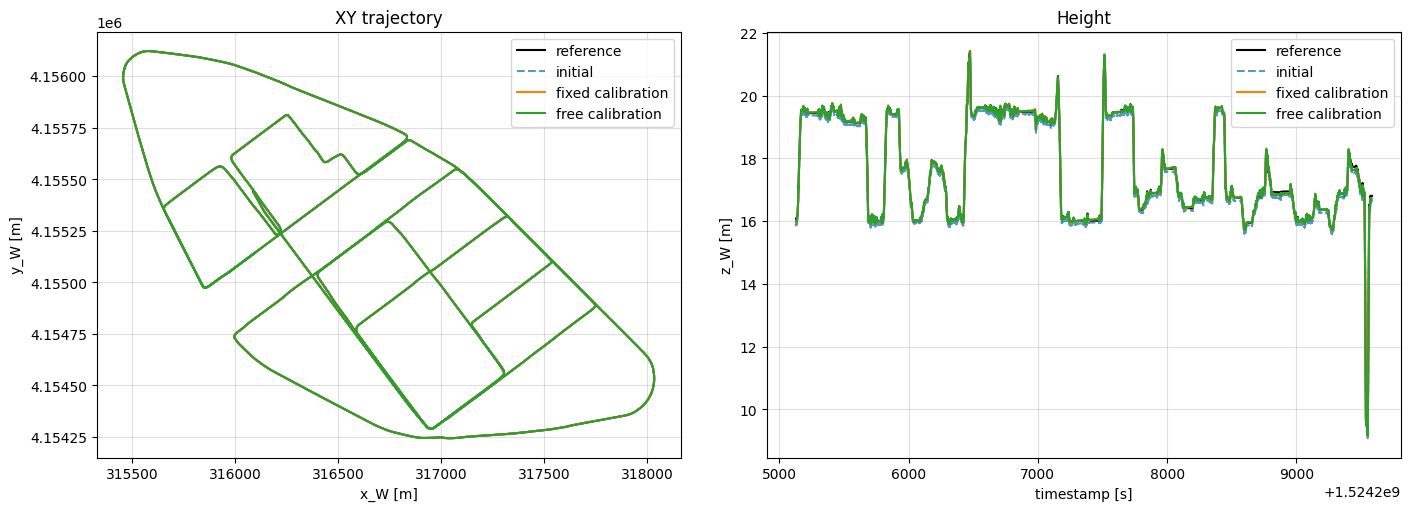

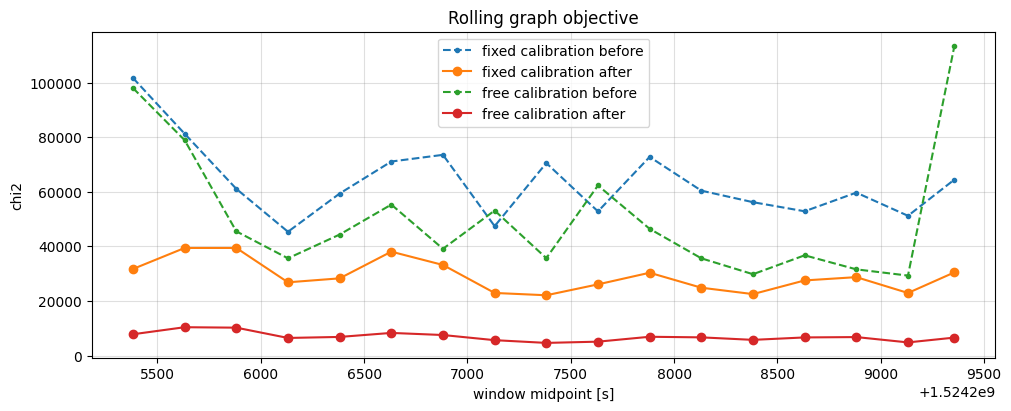

In [10]:
reference_mask = (true_timestamps >= perturbed.pose_timestamps_s[0]) & (true_timestamps <= perturbed.pose_timestamps_s[-1])
fig, axes = plot_fixed_free_trajectories(
    runs,
    reference_timestamps=true_timestamps[reference_mask],
    reference_poses=true_poses[reference_mask],
    initial_timestamps=perturbed.pose_timestamps_s,
    initial_poses=perturbed.initial_body_poses_T_W_B,
)
if SAVE_FIGURES:
    fig.savefig(OUT / 'fixed_vs_free_trajectory.png', dpi=160)
plt.show()
plt.close(fig)

fig, axis = plot_fixed_free_chi2(runs)
if SAVE_FIGURES:
    fig.savefig(OUT / 'fixed_vs_free_chi2.png', dpi=160)
plt.show()
plt.close(fig)

## 11. Calibration Tracking Against Injected Truth

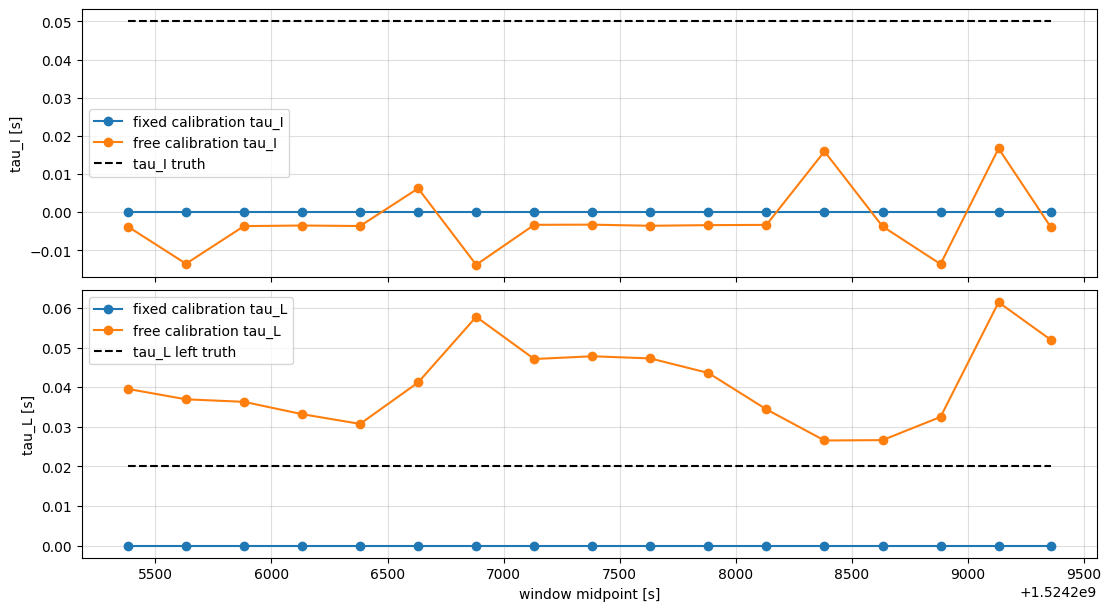

In [11]:
fig, axes = plot_calibration_truth_tracking(runs, laws)
if SAVE_FIGURES:
    fig.savefig(OUT / 'fixed_vs_free_tau_tracking.png', dpi=160)
plt.show()
plt.close(fig)

## 12. Notes

- The LiDAR inputs are absolute `T_W_L` pose observations from scan-to-map localization and are consumed by `LidarPoseStream`.
- No relative LiDAR odometry factors are used here.
- The fixed graph intentionally anchors calibration variables at the nominal values while consuming perturbed data.
- The free graph starts from the same nominal values but allows calibration variables to move, with rolling optimized priors for continuity.

In [12]:
estimated_timestamps_fixed, estimated_poses_fixed = fixed_run.graph.rolling_state.rolling_trajectory
estimated_timestamps_free, estimated_poses_free = free_run.graph.rolling_state.rolling_trajectory
estimated_poses_world_fixed = estimated_poses_fixed
estimated_poses_world_free = estimated_poses_free

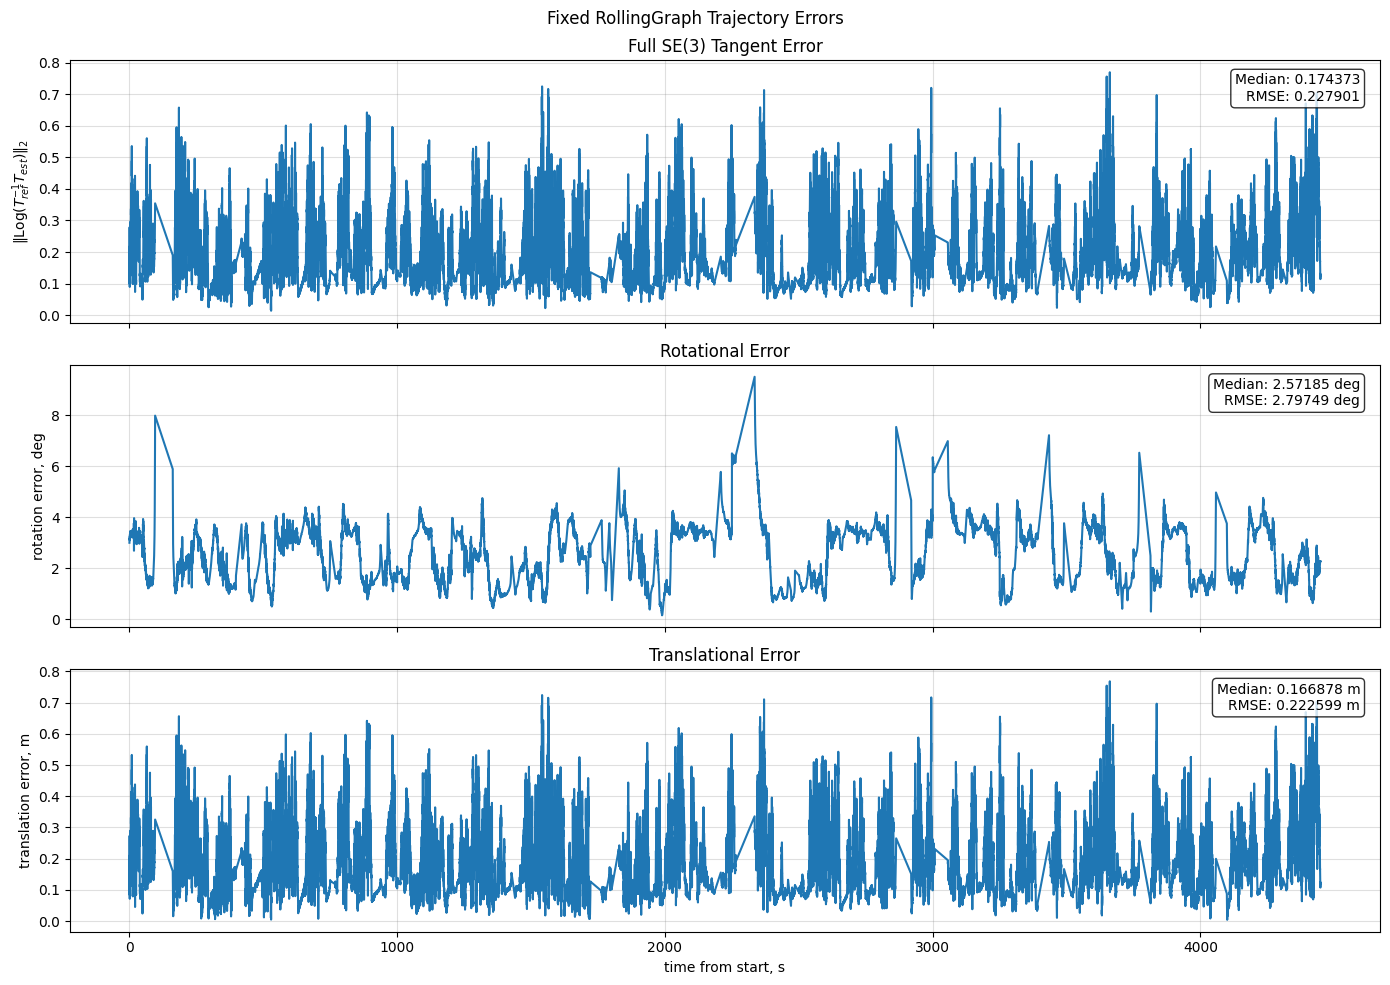

{'se3': {'median': 0.17437289382941942, 'rmse': 0.22790137755271744},
 'rotation_deg': {'median': 2.571846779229909, 'rmse': 2.79749266640779},
 'translation_m': {'median': 0.166877535537986, 'rmse': 0.22259906982231395}}

In [13]:
fig, axes, trajectory_error_statistics_fixed = multi_sensor_pipeline.plotting.plot_trajectory_errors(
    estimated_timestamps=estimated_timestamps_fixed,
    estimated_poses=estimated_poses_world_fixed,
    reference_timestamps=true_timestamps,
    reference_poses=true_poses,
    title="Fixed RollingGraph Trajectory Errors",
    relative_time=True,
)

if SAVE_FIGURES:
    fig.savefig(OUT / 'rolling_graph_trajectory_errors_fixed.png', dpi=160)

plt.show()
plt.close(fig)

trajectory_error_statistics_fixed

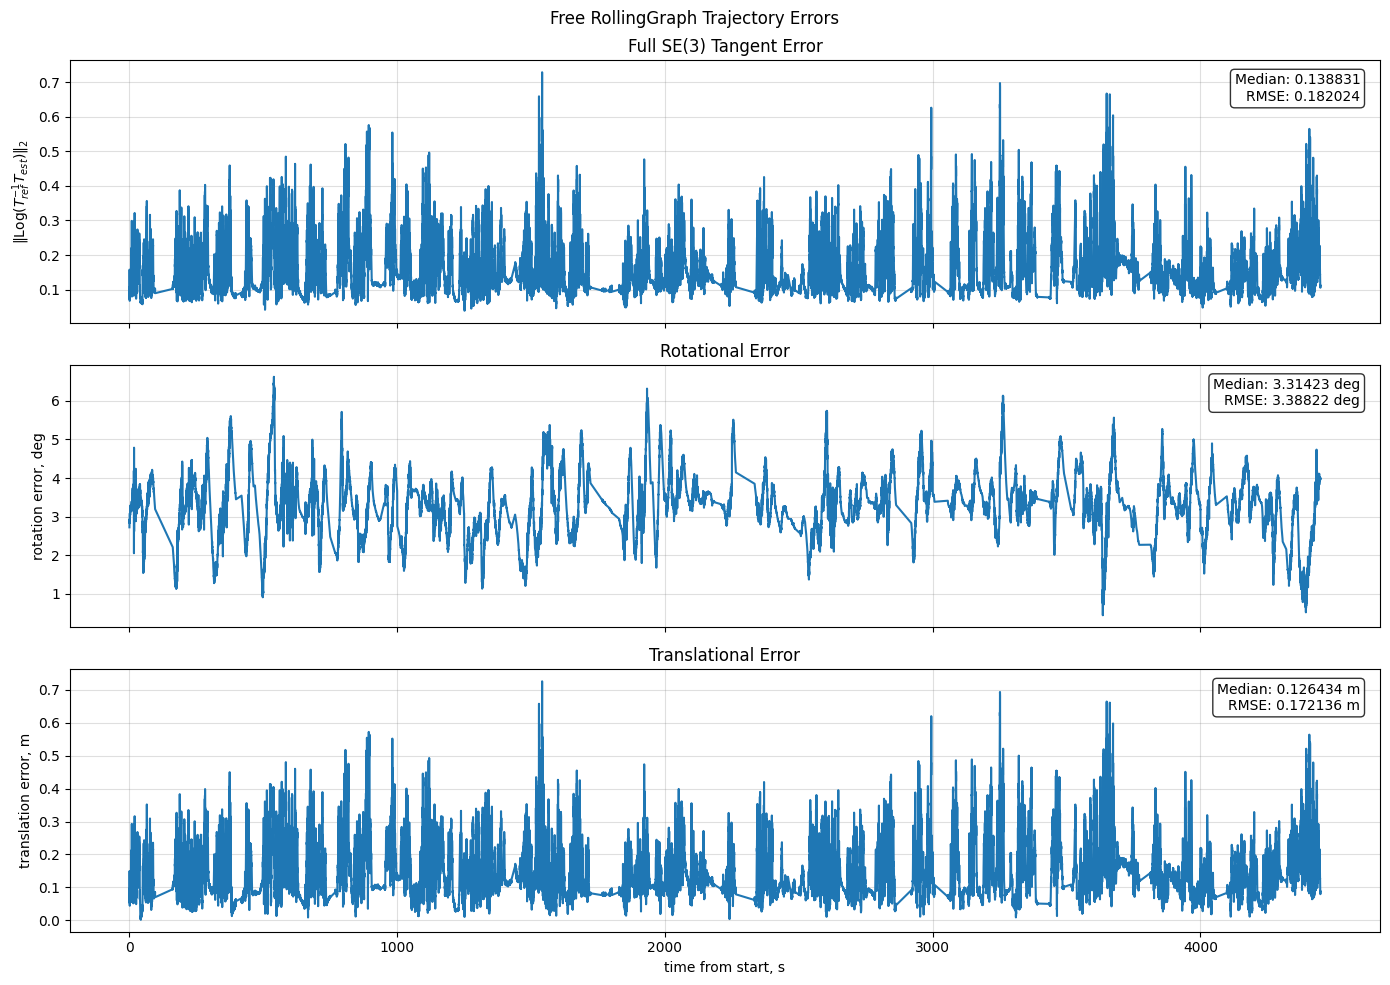

{'se3': {'median': 0.13883078300893073, 'rmse': 0.18202442641021668},
 'rotation_deg': {'median': 3.314230760233953, 'rmse': 3.3882201136223595},
 'translation_m': {'median': 0.12643360209517254, 'rmse': 0.17213629683138812}}

In [14]:
fig, axes, trajectory_error_statistics_free = multi_sensor_pipeline.plotting.plot_trajectory_errors(
    estimated_timestamps=estimated_timestamps_free,
    estimated_poses=estimated_poses_world_free,
    reference_timestamps=true_timestamps,
    reference_poses=true_poses,
    title="Free RollingGraph Trajectory Errors",
    relative_time=True,
)

if SAVE_FIGURES:
    fig.savefig(OUT / 'rolling_graph_trajectory_errors_free.png', dpi=160)

plt.show()
plt.close(fig)

trajectory_error_statistics_free